c:\Users\Dede\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Sedang melatih model...
Epoch 1/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7186 - loss: 0.4939 - val_accuracy: 0.7338 - val_loss: 0.4607
Epoch 2/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7368 - loss: 0.4523 - val_accuracy: 0.7521 - val_loss: 0.4282
Epoch 3/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7664 - loss: 0.4139 - val_accuracy: 0.7837 - val_loss: 0.3923
Epoch 4/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7996 - loss: 0.3678 - val_accuracy: 0.8096 - val_loss: 0.3417
Epoch 5/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8401 - loss: 0.3183 - val_accuracy: 0.8728 - val_loss: 0.2935
Epoch 6/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8721 - loss: 0.2760 - val_accuracy: 0.8829 - val_loss: 0.2655
Epoch 7/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8950 - loss: 0.2422 - val_accuracy: 0.9068 - val_loss: 0.2345
Epoch 8/100
768/768 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9115 -

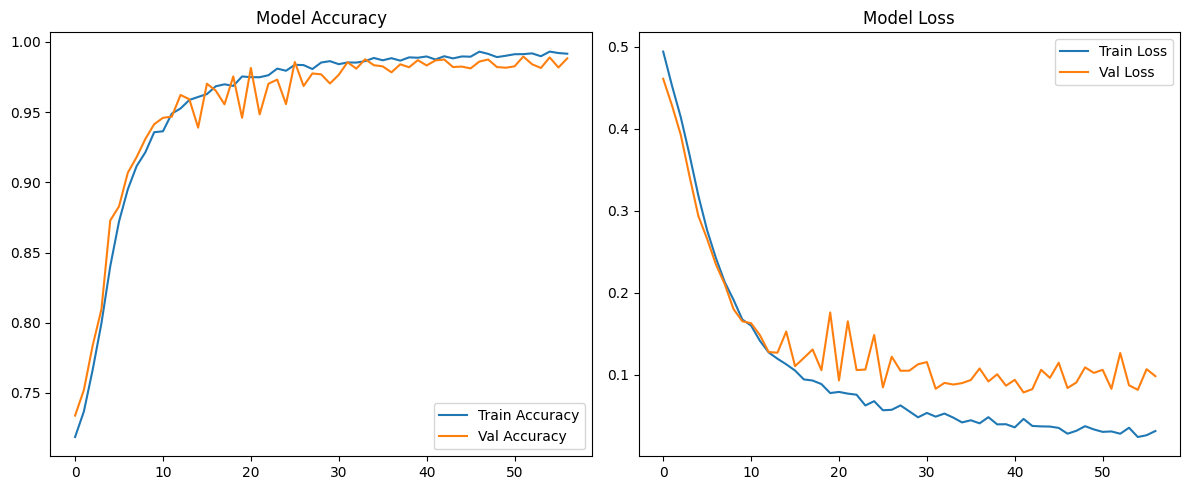


Model dan Scaler berhasil disimpan!


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# Import tambahan untuk evaluasi & visualisasi
from sklearn.metrics import classification_report, mean_squared_error
import matplotlib.pyplot as plt
import pickle

# 1. Memuat Dataset
file_path = "Liver Patient Dataset (LPD)_train.csv"
dataset = pd.read_csv(file_path, encoding='latin1')

# 2. Preprocessing Data
dataset.columns = dataset.columns.str.strip()
dataset = dataset.fillna(dataset.median(numeric_only=True))

# 3. Konversi Gender ke Angka
gender_col = [col for col in dataset.columns if 'gender' in col.lower()]
if gender_col:
    dataset[gender_col[0]] = dataset[gender_col[0]].fillna(dataset[gender_col[0]].mode()[0])
    dataset[gender_col[0]] = dataset[gender_col[0]].map({'Male': 1, 'Female': 0})

# Transformasi label Result: 1 (Sakit) -> 1, 2 (Sehat) -> 0
target_col = dataset.columns[-1]
dataset[target_col] = dataset[target_col].map({1: 1, 2: 0})

# 4. Pisahkan fitur (X) dan target (y)
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# 5. Normalisasi dan Split Data
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 6. Membangun Model (Sesuai arsitektur aslimu)
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 7. Pelatihan Model (Simpan ke 'history' untuk grafik)
print("Sedang melatih model...")
history = model.fit(X_train, y_train, epochs=100, batch_size=32, 
                    validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# 8. Evaluasi Akhir
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nAkurasi Final: {accuracy * 100:.2f}%")

# --- EVALUASI MENDALAM ---
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Sehat', 'Sakit']))

# --- VISUALISASI ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

# --- SIMPAN UNTUK FLASK ---
model.save('model_liver.h5')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)
print("\nModel dan Scaler berhasil disimpan!")